# Skin Cancer (ISIC 2019-2020) — Exploratory Data Analysis
### Malignant vs Benign — Image Classification EDA

**Goal of this notebook:**
- Understand dataset size, structure, and label format
- Check class distribution and class imbalance (per split and overall)
- Inspect image properties (dimensions, aspect ratio, file size, color stats)
- Visualize sample images per class
- Check for corrupted / unreadable images
- Check for duplicate images (a common issue in dermatology datasets)
- Summarize findings that will drive preprocessing / augmentation / training decisions

**Expected folder structure (as provided by the user, in Google Drive):**
```
skin_dataset_reszie/
├── train/
│   ├── malignant/
│   └── benign/
├── val/
│   ├── malignant/
│   └── benign/
└── test/
    ├── malignant/
    └── benign/
```

This notebook is designed to run on **Google Colab**. Just set `DATASET_PATH` in the cell below to the
path of `skin_dataset_reszie` inside your Google Drive, and run all cells top-to-bottom.


## 1. Setup — Mount Google Drive & Install/Import Libraries

In [1]:
# Mount Google Drive (skip this cell if the dataset is already local to the Colab runtime)
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# Install any missing packages (Colab usually has these pre-installed already)
!pip install -q opencv-python-headless pillow matplotlib seaborn pandas tqdm


In [3]:
import os
import cv2
import glob
import random
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm
from collections import defaultdict

sns.set_style("whitegrid")
plt.rcParams["figure.facecolor"] = "white"
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Set Dataset Path

Change `DATASET_PATH` below to point to your `skin_dataset_reszie` folder inside Google Drive.

Example:
```python
DATASET_PATH = "/content/drive/MyDrive/FYP/skin_dataset_reszie"
```


In [4]:
# Unzip a folder
# Replace 'your_zip_file.zip' with the path to your .zip file
# Replace 'destination_folder' with the path where you want to extract the files
!unzip -q "/content/drive/MyDrive/archive (1).zip" -d "/content/destination"

# Example: Unzipping a file from Google Drive into /content/data
# !unzip -q "/content/drive/MyDrive/my_dataset.zip" -d "/content/data"

print("Unzipping complete.")

Unzipping complete.


In [5]:
# ============================================================
# >>> EDIT THIS PATH <<<
DATASET_PATH = "/content/destination/skin_dataset_resized"
# ============================================================

SPLITS = ["train_set", "val_set", "test_set"]
CLASSES = ["benign", "malignant"]
VALID_EXTS = (".jpg", ".jpeg", ".png", ".bmp")

# Quick sanity check that the folder structure exists
for split in SPLITS:
    for cls in CLASSES:
        p = os.path.join(DATASET_PATH, split, cls)
        exists = os.path.isdir(p)
        print(f"{p:70s} -> {'FOUND' if exists else 'MISSING'}")


/content/destination/skin_dataset_resized/train_set/benign             -> FOUND
/content/destination/skin_dataset_resized/train_set/malignant          -> FOUND
/content/destination/skin_dataset_resized/val_set/benign               -> FOUND
/content/destination/skin_dataset_resized/val_set/malignant            -> FOUND
/content/destination/skin_dataset_resized/test_set/benign              -> FOUND
/content/destination/skin_dataset_resized/test_set/malignant           -> FOUND


## 3. Dataset Size & Class Distribution (Counts)

In [6]:
def list_images(folder):
    files = []
    for ext in VALID_EXTS:
        files.extend(glob.glob(os.path.join(folder, f"*{ext}")))
        files.extend(glob.glob(os.path.join(folder, f"*{ext.upper()}")))
    return files

# Build a dictionary: counts[split][class] = number of images
counts = defaultdict(dict)
file_paths = defaultdict(dict)  # keep the actual paths for later use

for split in SPLITS:
    for cls in CLASSES:
        folder = os.path.join(DATASET_PATH, split, cls)
        imgs = list_images(folder) if os.path.isdir(folder) else []
        counts[split][cls] = len(imgs)
        file_paths[split][cls] = imgs

count_df = pd.DataFrame(counts).T  # rows = split, cols = class
count_df["total"] = count_df.sum(axis=1)
count_df.loc["total"] = count_df.sum()
count_df


,benign,malignant,total
train_set,5200,4000,9200
val_set,550,550,1100
test_set,550,550,1100
total,6300,5100,11400


**What to look at here:**
- Total number of images in the whole dataset (bottom-right cell).
- Per-split totals (train should be the largest, val/test smaller).
- Per-class totals — this is our first look at class imbalance.


## 4. Class Imbalance — Percentages

In [7]:
# Percentage of each class within each split
pct_df = count_df.drop(index="total").drop(columns="total").copy()
pct_df = pct_df.div(pct_df.sum(axis=1), axis=0) * 100
pct_df = pct_df.round(2)
print("Class percentage within each split:")
pct_df


Class percentage within each split:


,benign,malignant
train_set,56.52,43.48
val_set,50.00,50.00
test_set,50.00,50.00


In [8]:
# Overall class distribution across the WHOLE dataset (train+val+test combined)
overall_counts = count_df.drop(index="total")[CLASSES].sum()
overall_pct = (overall_counts / overall_counts.sum() * 100).round(2)

overall_summary = pd.DataFrame({
    "total_images": overall_counts,
    "percentage": overall_pct
})
print(f"TOTAL images in dataset: {int(overall_counts.sum())}\n")
overall_summary


TOTAL images in dataset: 11400



,total_images,percentage
benign,6300,55.26
malignant,5100,44.74


In [9]:
# Imbalance ratio (majority class count / minority class count)
majority = overall_counts.max()
minority = overall_counts.min()
imbalance_ratio = majority / minority
print(f"Majority class: {overall_counts.idxmax()} ({int(majority)} images)")
print(f"Minority class: {overall_counts.idxmin()} ({int(minority)} images)")
print(f"Imbalance ratio (majority:minority) = {imbalance_ratio:.2f} : 1")

if imbalance_ratio < 1.5:
    verdict = "Roughly balanced — minimal action needed."
elif imbalance_ratio < 3:
    verdict = "Moderate imbalance — class weighting or mild oversampling recommended."
else:
    verdict = "Severe imbalance — weighted loss, oversampling/undersampling, or focal loss strongly recommended."

print(f"\nVerdict: {verdict}")


Majority class: benign (6300 images)
Minority class: malignant (5100 images)
Imbalance ratio (majority:minority) = 1.24 : 1

Verdict: Roughly balanced — minimal action needed.


## 5. Visualizing Class Distribution

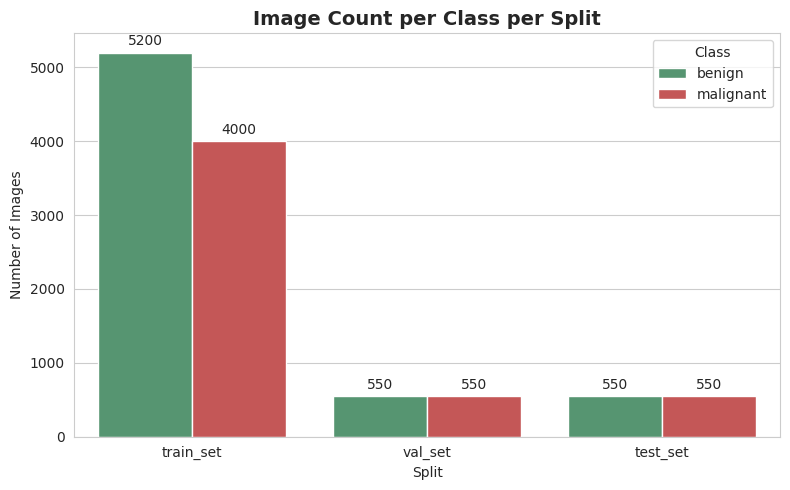

In [10]:
# Bar chart: image counts per class per split
plot_df = count_df.drop(index="total")[CLASSES].reset_index().rename(columns={"index": "split"})
plot_melt = plot_df.melt(id_vars="split", var_name="class", value_name="count")

plt.figure(figsize=(8, 5))
sns.barplot(data=plot_melt, x="split", y="count", hue="class", palette={"benign": "#4C9F70", "malignant": "#D64545"})
plt.title("Image Count per Class per Split", fontsize=14, fontweight="bold")
plt.ylabel("Number of Images")
plt.xlabel("Split")
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt="%d", padding=3)
plt.legend(title="Class")
plt.tight_layout()
plt.show()


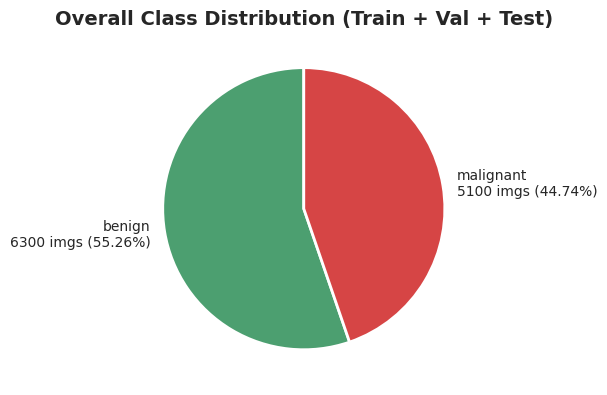

In [11]:
# Pie chart: overall class distribution (whole dataset)
plt.figure(figsize=(6, 6))
colors = ["#4C9F70", "#D64545"]
plt.pie(
    overall_counts,
    labels=[f"{cls}\n{int(cnt)} imgs ({pct}%)" for cls, cnt, pct in
            zip(overall_counts.index, overall_counts.values, overall_pct.values)],
    colors=colors,
    autopct=None,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
plt.title("Overall Class Distribution (Train + Val + Test)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


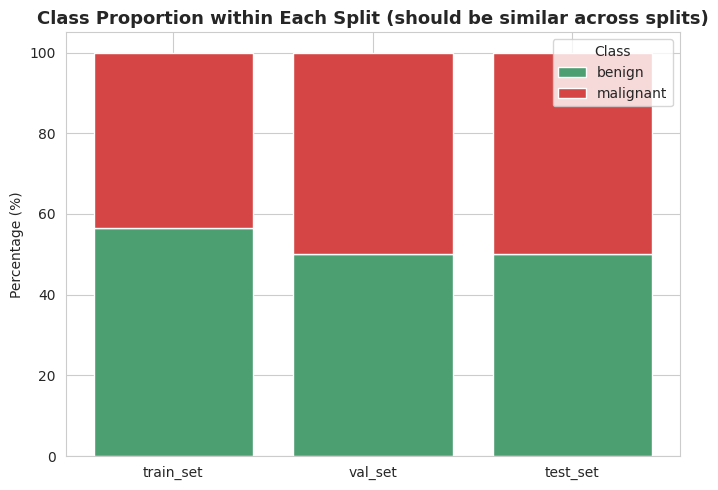

In [12]:
# Stacked 100% bar chart: class proportion within each split (useful to confirm splits are stratified)
pct_plot = pct_df.reset_index().rename(columns={"index": "split"})
fig, ax = plt.subplots(figsize=(7, 5))
bottom = np.zeros(len(pct_plot))
for cls, color in zip(CLASSES, colors):
    ax.bar(pct_plot["split"], pct_plot[cls], bottom=bottom, label=cls, color=color)
    bottom += pct_plot[cls].values
ax.set_ylabel("Percentage (%)")
ax.set_title("Class Proportion within Each Split (should be similar across splits)", fontsize=13, fontweight="bold")
ax.legend(title="Class")
plt.tight_layout()
plt.show()


**Interpretation:**
- If the malignant/benign proportion is very different between train, val, and test, this means the split
  was not stratified — which can bias validation/test metrics. Ideally each split should have roughly the
  same benign:malignant ratio.


## 6. Sample Images per Class

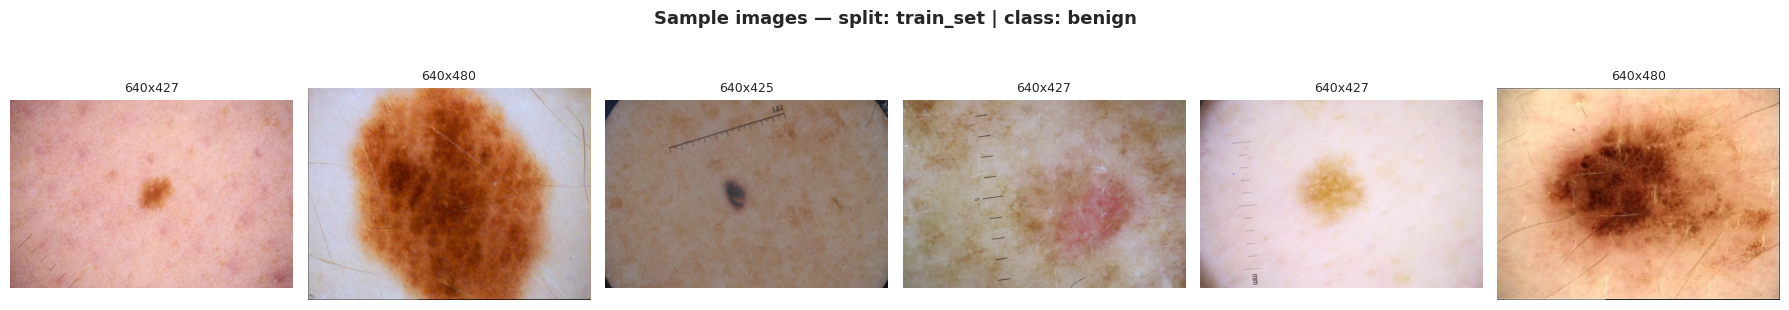

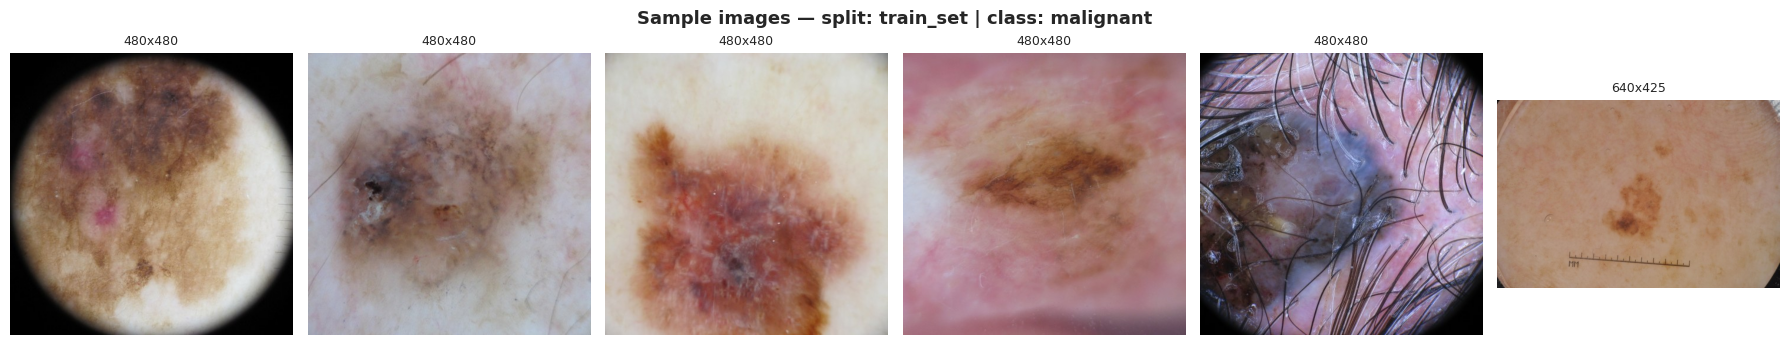

In [13]:
def show_samples(split, cls, n=6):
    paths = file_paths[split][cls]
    if len(paths) == 0:
        print(f"No images found for {split}/{cls}")
        return
    sample_paths = random.sample(paths, min(n, len(paths)))
    fig, axes = plt.subplots(1, len(sample_paths), figsize=(3*len(sample_paths), 3.5))
    if len(sample_paths) == 1:
        axes = [axes]
    for ax, p in zip(axes, sample_paths):
        img = Image.open(p).convert("RGB")
        ax.imshow(img)
        ax.set_title(f"{img.size[0]}x{img.size[1]}", fontsize=9)
        ax.axis("off")
    fig.suptitle(f"Sample images — split: {split} | class: {cls}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

show_samples("train_set", "benign", n=6)
show_samples("train_set", "malignant", n=6)


Look for visible differences between classes (asymmetry, border irregularity, color variation —
typical dermoscopic ABCDE features), and note any obvious artifacts (rulers, ink markings, hair, black
borders/vignettes) that are common in dermoscopy datasets and may need to be handled during preprocessing.


## 7. Image Dimension & Aspect Ratio Analysis

In [14]:
# Sample a subset of images per split/class to keep this fast (increase sample_size for a fuller picture)
sample_size = 300  # per class per split; set to None to scan ALL images (slower)

dim_records = []
for split in SPLITS:
    for cls in CLASSES:
        paths = file_paths[split][cls]
        chosen = paths if sample_size is None else random.sample(paths, min(sample_size, len(paths)))
        for p in tqdm(chosen, desc=f"{split}/{cls}", leave=False):
            try:
                with Image.open(p) as img:
                    w, h = img.size
                    mode = img.mode
                dim_records.append({
                    "split": split, "class": cls, "path": p,
                    "width": w, "height": h, "aspect_ratio": round(w/h, 3), "mode": mode,
                    "filesize_kb": round(os.path.getsize(p) / 1024, 1)
                })
            except Exception as e:
                dim_records.append({
                    "split": split, "class": cls, "path": p,
                    "width": None, "height": None, "aspect_ratio": None,
                    "mode": None, "filesize_kb": None, "error": str(e)
                })

dim_df = pd.DataFrame(dim_records)
print(f"Analyzed {len(dim_df)} sampled images.")
dim_df.head()


train_set/benign:   0%|          | 0/300 [00:00<?, ?it/s]

train_set/malignant:   0%|          | 0/300 [00:00<?, ?it/s]

val_set/benign:   0%|          | 0/300 [00:00<?, ?it/s]

val_set/malignant:   0%|          | 0/300 [00:00<?, ?it/s]

test_set/benign:   0%|          | 0/300 [00:00<?, ?it/s]

test_set/malignant:   0%|          | 0/300 [00:00<?, ?it/s]

Analyzed 1800 sampled images.


,split,class,path,width,height,aspect_ratio,mode,filesize_kb
0,train_set,benign,/content/destination/skin_dataset_resized/trai...,640,360,1.778,RGB,28.8
1,train_set,benign,/content/destination/skin_dataset_resized/trai...,640,360,1.778,RGB,35.1
2,train_set,benign,/content/destination/skin_dataset_resized/trai...,640,425,1.506,RGB,32.8
3,train_set,benign,/content/destination/skin_dataset_resized/trai...,640,360,1.778,RGB,32.7
4,train_set,benign,/content/destination/skin_dataset_resized/trai...,640,360,1.778,RGB,28.7


In [ ]:
# Summary statistics of width/height/filesize
dim_df[["width", "height", "aspect_ratio", "filesize_kb"]].describe()


,width,height,aspect_ratio,filesize_kb
count,1800.000000,1800.000000,1800.000000,1800.000000
mean,620.684444,441.521111,1.426246,38.830667
std,52.009912,45.443434,0.223644,10.853279
min,319.000000,360.000000,0.665000,12.500000
25%,640.000000,425.000000,1.333000,30.700000
50%,640.000000,478.000000,1.339000,37.200000
75%,640.000000,480.000000,1.506000,45.825000
max,640.000000,480.000000,1.778000,92.600000


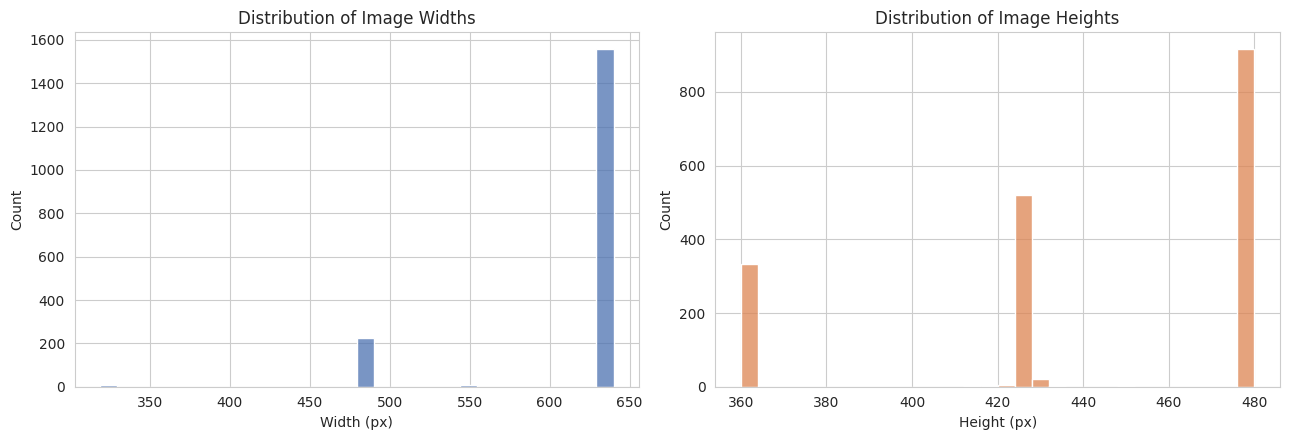

Number of distinct (width, height) combinations found in the sample: 27
Images have varying resolutions — resizing to a fixed input size will be required before training.


In [15]:
# Distribution of image widths and heights
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(dim_df["width"].dropna(), bins=30, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of Image Widths")
axes[0].set_xlabel("Width (px)")

sns.histplot(dim_df["height"].dropna(), bins=30, ax=axes[1], color="#DD8452")
axes[1].set_title("Distribution of Image Heights")
axes[1].set_xlabel("Height (px)")
plt.tight_layout()
plt.show()

n_unique_sizes = dim_df.dropna(subset=["width","height"]).apply(lambda r: (r.width, r.height), axis=1).nunique()
print(f"Number of distinct (width, height) combinations found in the sample: {n_unique_sizes}")
if n_unique_sizes == 1:
    print("All sampled images share the same resolution — dataset appears pre-resized (consistent with the 'resize' folder name).")
else:
    print("Images have varying resolutions — resizing to a fixed input size will be required before training.")


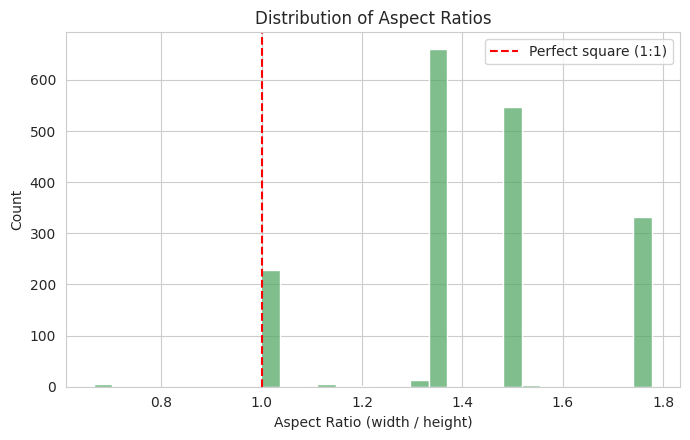

In [16]:
# Aspect ratio distribution — check if images are mostly square or vary a lot
plt.figure(figsize=(7, 4.5))
sns.histplot(dim_df["aspect_ratio"].dropna(), bins=30, color="#55A868")
plt.axvline(1.0, color="red", linestyle="--", label="Perfect square (1:1)")
plt.title("Distribution of Aspect Ratios")
plt.xlabel("Aspect Ratio (width / height)")
plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipykernel_1295/1721476460.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dim_df, x="class", y="filesize_kb", palette={"benign": "#4C9F70", "malignant": "#D64545"})


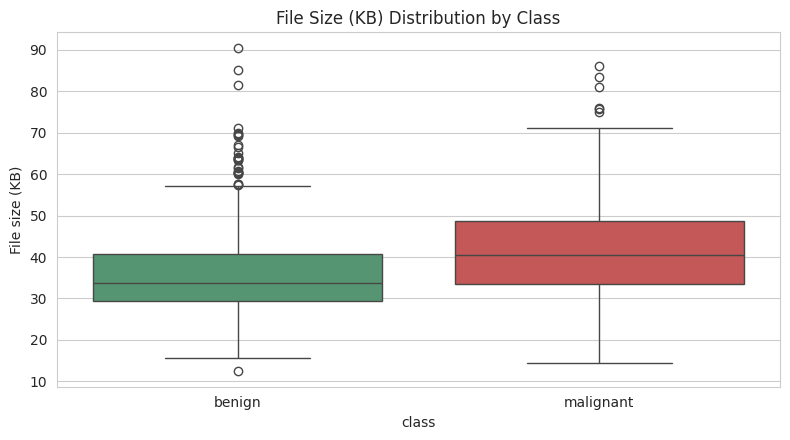

In [17]:
# File size distribution by class (can reveal compression / quality differences between classes)
plt.figure(figsize=(8, 4.5))
sns.boxplot(data=dim_df, x="class", y="filesize_kb", palette={"benign": "#4C9F70", "malignant": "#D64545"})
plt.title("File Size (KB) Distribution by Class")
plt.ylabel("File size (KB)")
plt.tight_layout()
plt.show()


**Why this matters:**
- If all images already share one resolution, the "resize" step has already been done for you — great,
  less preprocessing work.
- Aspect ratio close to 1:1 confirms images are square (typical after a center-crop/resize pipeline).
- Large file-size differences between classes could hint at different image sources/compression, which
  is worth knowing so the model doesn't learn a shortcut based on compression artifacts instead of the lesion itself.


## 8. Color / Pixel Intensity Analysis

In [18]:
# Average color channel intensity per class (RGB) - helps spot systematic color differences
color_sample_size = 150  # per class, keep small since this reads full pixel data

color_records = []
for cls in CLASSES:
    paths = file_paths["train_set"][cls]
    chosen = random.sample(paths, min(color_sample_size, len(paths)))
    for p in tqdm(chosen, desc=f"color:{cls}", leave=False):
        try:
            img = cv2.imread(p)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            mean_rgb = img.reshape(-1, 3).mean(axis=0)
            color_records.append({"class": cls, "R": mean_rgb[0], "G": mean_rgb[1], "B": mean_rgb[2],
                                   "brightness": mean_rgb.mean()})
        except Exception:
            continue

color_df = pd.DataFrame(color_records)
color_df.groupby("class")[["R", "G", "B", "brightness"]].mean().round(2)


color:benign:   0%|          | 0/150 [00:00<?, ?it/s]

color:malignant:   0%|          | 0/150 [00:00<?, ?it/s]

,R,G,B,brightness
class,,,,
benign,193.33,145.99,130.26,156.53
malignant,157.14,131.84,126.69,138.56


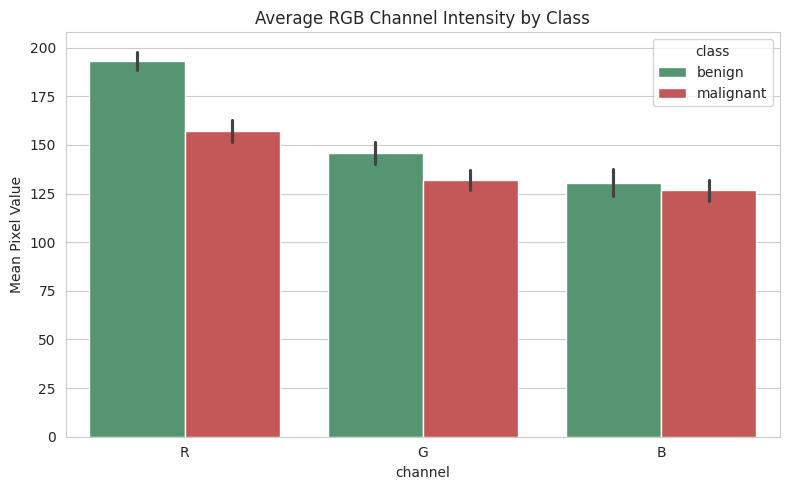

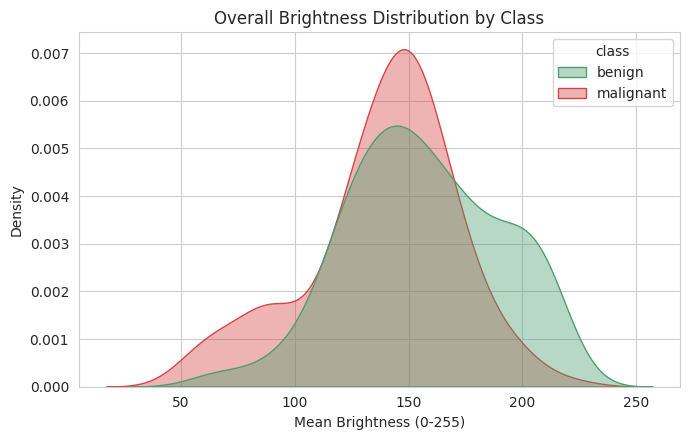

In [19]:
# Visualize average channel intensity per class
melt_color = color_df.melt(id_vars="class", value_vars=["R", "G", "B"], var_name="channel", value_name="mean_value")
plt.figure(figsize=(8, 5))
sns.barplot(data=melt_color, x="channel", y="mean_value", hue="class",
            palette={"benign": "#4C9F70", "malignant": "#D64545"})
plt.title("Average RGB Channel Intensity by Class")
plt.ylabel("Mean Pixel Value")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.5))
sns.kdeplot(data=color_df, x="brightness", hue="class",
            palette={"benign": "#4C9F70", "malignant": "#D64545"}, fill=True, alpha=0.4)
plt.title("Overall Brightness Distribution by Class")
plt.xlabel("Mean Brightness (0-255)")
plt.tight_layout()
plt.show()


If brightness/color distributions differ noticeably between classes, this is a signal that
normalization (e.g. per-channel mean/std normalization, or color constancy techniques common in
dermoscopy pipelines like shades-of-gray) should be part of the preprocessing pipeline, so the model
generalizes on lesion morphology rather than incidental lighting/color differences.


## 9. Corrupted / Unreadable Image Check

In [20]:
def check_corrupt(paths):
    corrupt = []
    for p in tqdm(paths, desc="Checking integrity", leave=False):
        try:
            with Image.open(p) as img:
                img.verify()
        except Exception as e:
            corrupt.append((p, str(e)))
    return corrupt

all_paths = [p for split in SPLITS for cls in CLASSES for p in file_paths[split][cls]]
print(f"Checking integrity of {len(all_paths)} total images... (this may take a while for large datasets)")

corrupt_files = check_corrupt(all_paths)
print(f"\nFound {len(corrupt_files)} corrupted/unreadable image(s).")
if corrupt_files:
    for p, err in corrupt_files[:20]:
        print(f" - {p} | {err}")


Checking integrity of 11400 total images... (this may take a while for large datasets)


Checking integrity:   0%|          | 0/11400 [00:00<?, ?it/s]


Found 0 corrupted/unreadable image(s).


## 10. Summary of Findings

In [21]:
print("="*70)
print("EDA SUMMARY")
print("="*70)
print(f"Total images in dataset      : {int(overall_counts.sum())}")
for cls in CLASSES:
    print(f"  - {cls:10s}: {int(overall_counts[cls])} images ({overall_pct[cls]}%)")
print(f"Class imbalance ratio         : {imbalance_ratio:.2f} : 1  ->  {verdict}")
print(f"Corrupted images found        : {len(corrupt_files)}")
print("="*70)


EDA SUMMARY
Total images in dataset      : 11400
  - benign    : 6300 images (55.26%)
  - malignant : 5100 images (44.74%)
Class imbalance ratio         : 1.24 : 1  ->  Roughly balanced — minimal action needed.
Corrupted images found        : 0


### Key takeaways to carry into modeling (fill in / adjust after running the notebook on your data):

1. **Class imbalance** — if the ratio printed above is above ~2:1, plan to use class-weighted loss,
   oversampling of the minority class, or focal loss during training.
2. **Split integrity** — confirm class proportions are similar across train/val/test, and confirm there
   is **no duplicate leakage** across splits (critical for trustworthy evaluation).
3. **Image consistency** — since the folder is named "resize", images are likely already a fixed size;
   confirm this above and pick your model's input size accordingly (e.g. 224x224 for standard
   ImageNet-pretrained CNNs).
4. **Color/brightness differences** — if found, plan for normalization/color-constancy preprocessing.
5. **Artifacts** — hair, rulers, ink marks, or black vignette borders visible in the sample grid may need
   dedicated preprocessing (e.g. hair removal via morphological filtering, black-border cropping) commonly
   used in dermoscopy pipelines.
6. **Corrupted/duplicate files** — remove or fix any corrupted images before training; decide whether to
   keep or de-duplicate redundant images (duplicates within the *same* split are less harmful but still
   worth knowing about).

This EDA output directly informs the preprocessing, augmentation, and model/training decisions for the
next stage of the assessment (baseline CNN + fine-tuned transfer-learning model).
